# TP : Détection de Points Clés Faciaux par Transfer Learning avec ResNet-50

## Le Facial Keypoints Dataset

Le **Facial Keypoints Dataset** (de Udacity) est un dataset conçu pour la détection de points clés faciaux (facial landmark detection).

#### Contenu du Dataset

- **Images** : Photos de visages en niveaux de gris ou couleur
- **Keypoints** : 68 points clés par visage qui marquent les contours et caractéristiques faciales
- **Format** : Fichiers CSV contenant les chemins des images et les coordonnées (x, y) de chaque point

#### Utilisation

- **Régression de keypoints** : prédire les coordonnées (x, y) de chaque point
- **Détection d'émotions** : analyser les expressions faciales
- **Alignement de visages** : normaliser l'orientation
- **Applications AR/VR** : filtres et effets faciaux

⚠️ Les transformations géométriques (rotation, crop, flip) doivent être appliquées **simultanément** aux images ET aux keypoints pour maintenir la cohérence !

#### Les 68 Points Clés

Ces points suivent une disposition standardisée visible [ici](http://web.gregory-bourguin.fr/images/computer_vision/landmarks_numbered.jpg).

### Télécharger le Facial Keypoints Dataset

Si ce n'est pas déjà fait, décommentez et exécutez les commandes suivantes :
- Créer le dossier `../data` s'il n'existe pas déjà avec `mkdir -p`
- Cloner le dépôt GitHub du projet P1_Facial_Keypoints d'Udacity dans `../data/P1_Facial_Keypoints`

In [54]:
# !mkdir -p ../data
# !git clone https://github.com/udacity/P1_Facial_Keypoints.git ../data/P1_Facial_Keypoints

### Préparer l'environnement logiciel

Importez les bibliothèques nécessaires pour ce TP :
- `os` et `pandas` pour la manipulation de fichiers et données
- `sklearn.model_selection.train_test_split` pour diviser les données
- `PIL.Image` pour le chargement des images
- `torch`, `torch.nn`, `torch.optim` pour le deep learning avec PyTorch
- `torch.utils.data.Dataset` et `DataLoader` pour gérer les données
- `torchvision.models` pour charger ResNet-50 pré-entraîné
- `numpy` pour les opérations matricielles
- `matplotlib.pyplot` pour les visualisations
- `albumentations` pour les transformations d'images avec support des keypoints
- `tqdm.auto` pour les barres de progression

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from torchvision import models
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import albumentations as A
from tqdm.auto import tqdm
from torchsummary import summary

### Charger les données d'entraînement et créer un ensemble de validation

- Définir la variable `data_dir` pointant vers le dossier de données `'../data/P1_Facial_Keypoints/data/'`
- Construire le chemin vers le dossier d'entraînement `train_dir`
- Charger le fichier CSV `'training_frames_keypoints.csv'` dans un DataFrame `train_val_df`
- Utiliser `train_test_split` de scikit-learn pour diviser `train_val_df` en deux sous-ensembles : `train_df` (80 %) et `val_df` (20 %) avec `test_size=0.2` et `random_state=42`
- Afficher le nombre d'échantillons d'entraînement et de validation
- Afficher les premières lignes de `train_df` avec `display()`

In [2]:
data_dir = '../data/P1_Facial_Keypoints/data/'

train_dir = os.path.join(data_dir, 'training/')
train_val_df = pd.read_csv(os.path.join(data_dir, 'training_frames_keypoints.csv'))
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
display(train_df)

Training samples: 2769
Validation samples: 693


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,126,127,128,129,130,131,132,133,134,135
3177,Penelope_Ann_Miller_02.jpg,28.0,96.0,30.0,102.0,34.0,111.0,38.0,118.0,45.0,...,83.0,112.0,88.0,112.0,83.0,114.0,79.0,114.0,77.0,114.0
2475,Baburam_Bhattari_22.jpg,56.0,77.0,54.0,88.0,54.0,96.0,56.0,105.0,58.0,...,73.0,109.0,83.0,108.0,73.0,109.0,71.0,109.0,69.0,109.0
1399,Hanan_Ashrawi_21.jpg,44.0,93.0,47.0,102.0,49.0,113.0,51.0,121.0,55.0,...,98.0,128.0,104.0,126.0,98.0,128.0,93.0,128.0,89.0,128.0
729,Lino_Oviedo_30.jpg,28.0,48.0,26.0,53.0,28.0,58.0,28.0,62.0,28.0,...,39.0,68.0,44.0,69.0,39.0,69.0,38.0,69.0,36.0,69.0
1288,Estelle_Morris_31.jpg,38.0,82.0,38.0,92.0,38.0,102.0,40.0,110.0,43.0,...,94.0,116.0,99.0,118.0,94.0,116.0,89.0,116.0,84.0,113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Laura_Elena_Harring_00.jpg,27.0,76.0,29.0,83.0,31.0,90.0,32.0,97.0,36.0,...,69.0,91.0,75.0,94.0,68.0,96.0,66.0,98.0,61.0,98.0
1130,Jan_Peter_Balkenende_01.jpg,66.0,93.0,63.0,101.0,63.0,107.0,68.0,114.0,70.0,...,76.0,114.0,85.0,114.0,78.0,114.0,76.0,116.0,74.0,116.0
1294,Frank_Beamer_31.jpg,60.0,148.0,64.0,161.0,69.0,179.0,73.0,192.0,82.0,...,131.0,193.0,144.0,193.0,131.0,193.0,122.0,198.0,117.0,198.0
860,Frances_Fisher_40.jpg,70.0,120.0,70.0,138.0,74.0,153.0,78.0,168.0,81.0,...,137.0,176.0,151.0,177.0,137.0,176.0,129.0,176.0,122.0,176.0


### Charger les données de test

- Charger le fichier CSV `'test_frames_keypoints.csv'` dans un DataFrame `test_df`
- Afficher les premières lignes avec `display()`
- Afficher le nombre total d'échantillons de test

In [3]:
test_dir = os.path.join(data_dir, 'test/')
test_df = pd.read_csv(os.path.join(data_dir, 'test_frames_keypoints.csv'))
display(test_df)

print(f"Test samples: {len(test_df)}")

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,126,127,128,129,130,131,132,133,134,135
0,James_Wolfensohn_00.jpg,25.0,44.0,25.0,49.0,25.0,54.0,25.0,59.0,26.0,...,42.0,65.0,46.0,65.0,42.0,65.0,39.0,65.0,38.0,65.0
1,Valerie_Harper_30.jpg,55.0,62.0,52.0,72.0,52.0,83.0,55.0,90.0,55.0,...,78.0,104.0,88.0,106.0,78.0,106.0,75.0,104.0,70.0,104.0
2,Kristen_Breitweiser_11.jpg,60.0,88.0,60.0,98.0,63.0,109.0,65.0,116.0,68.0,...,96.0,114.0,106.0,117.0,96.0,117.0,94.0,117.0,89.0,117.0
3,Elizabeth_Dole_31.jpg,41.0,96.0,43.0,104.0,47.0,113.0,49.0,120.0,56.0,...,98.0,118.0,103.0,118.0,98.0,120.0,96.0,122.0,94.0,122.0
4,Kit_Bond_20.jpg,35.0,67.0,37.0,74.0,41.0,81.0,44.0,87.0,48.0,...,76.0,96.0,83.0,93.0,76.0,98.0,73.0,98.0,69.0,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,Massoud_Barzani_10.jpg,95.0,123.0,95.0,136.0,97.0,146.0,100.0,157.0,102.0,...,143.0,160.0,154.0,160.0,143.0,160.0,138.0,160.0,133.0,160.0
766,Olivia_Newton-John_10.jpg,81.0,112.0,81.0,125.0,84.0,137.0,87.0,149.0,90.0,...,139.0,156.0,148.0,159.0,139.0,159.0,133.0,159.0,130.0,159.0
767,Erin_Hershey_Presley_41.jpg,80.0,94.0,80.0,106.0,80.0,118.0,83.0,130.0,86.0,...,113.0,134.0,129.0,140.0,113.0,143.0,107.0,143.0,104.0,140.0
768,James_Wolfensohn_50.jpg,20.0,107.0,23.0,122.0,27.0,133.0,31.0,148.0,42.0,...,108.0,142.0,115.0,142.0,108.0,146.0,104.0,145.0,100.0,145.0


Test samples: 770


### Implémenter la classe `FacesDataset`

Rédigez la classe `FacesDataset(Dataset)` héritant de `torch.utils.data.Dataset` pour gérer le chargement et la transformation des images de visages avec leurs keypoints. Cette classe doit gérer la particularité des keypoints : toute transformation géométrique appliquée à l'image doit être appliquée de manière synchronisée aux coordonnées des keypoints.

**Attributs de classe** :
- `IMG_SIZE = 224` : taille des images après redimensionnement
- `MEAN` et `STD` : tenseurs de normalisation ImageNet (RGB)
- `AUGMENTATION` : pipeline Albumentations pour l'entraînement incluant `Resize`, `HorizontalFlip`, `RandomBrightnessContrast`, `HueSaturationValue`, `Normalize` et `ToTensorV2` avec le paramètre `keypoint_params=A.KeypointParams(format='xy', remove_invisible=False)`
- `NO_AUMENTATION` : pipeline sans augmentation incluant uniquement `Resize`, `Normalize` et `ToTensorV2` avec les mêmes `keypoint_params`

**Constructeur `__init__(self, dataframe, root_dir, augment=False)`** :
- Stocker le DataFrame contenant les chemins et keypoints
- Stocker le répertoire racine des images
- Stocker le booléen `augment` pour activer/désactiver l'augmentation

**Méthode `__len__(self)`** :
- Retourner le nombre d'échantillons dans le DataFrame

**Méthode `__getitem__(self, idx)`** :
- Charger l'image avec PIL et la convertir en RGB puis en array NumPy
- Extraire les keypoints du DataFrame et les reformater en tableau de shape `(68, 2)`
- Convertir les keypoints en liste de tuples `(x, y)`
- Appliquer la transformation appropriée (`AUGMENTATION` ou `NO_AUMENTATION`) avec `image` et `keypoints`
- Normaliser les coordonnées des keypoints par `IMG_SIZE` pour les ramener dans [0, 1]
- Convertir les keypoints en tenseur aplati de 136 éléments
- Retourner le tuple `(image, keypoints)`

**Méthode statique `denormalize(sample)`** :
- Prendre un tuple `(image, keypoints)` normalisé
- Dénormaliser l'image en inversant la normalisation ImageNet
- Reconvertir en uint8 dans [0, 255]
- Dénormaliser les keypoints en multipliant par `IMG_SIZE`
- Retourner `(image_denorm, keypoints_denorm)`

**Méthode `show_random_samples(self, n_samples=8)`** :
- Sélectionner `n_samples` indices aléatoires
- Créer une grille de visualisation avec `matplotlib`
- Pour chaque indice, charger l'échantillon, le dénormaliser et l'afficher
- Superposer les keypoints avec `scatter` en rouge

In [4]:
# ATTENTION : UNE TRANSFORMATION GEOMETRIQUE SUR LES IMAGES DOIT ETRE APPLIQUEE AUSSI AUX POINTS CLÉS !!!

# NB : on devrait mettre cette classe dans un fichier séparé...
class FacesDataset(Dataset):

    IMG_SIZE = 224
    MEAN = torch.Tensor([0.485, 0.456, 0.406])
    STD = torch.Tensor([0.229, 0.224, 0.225])
    
    AUGMENTATION = A.Compose([
            # On ne fait pas de recadrage aléatoire ici car cela pourrait supprimer des keypoints importants
            # ce qui compliquerait la gestion des keypoints manquants.
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3),
            A.Normalize(mean=MEAN, std=STD),
            A.ToTensorV2()
        ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))
    
    NO_AUGMENTATION = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=MEAN, std=STD),
            A.ToTensorV2()
        ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

    def __init__(self, dataframe, root_dir, augment=False):
        """
        Initialize the FacesDataset.
        
        Parameters
        ----------
        dataframe : pandas.DataFrame
            DataFrame containing image filenames in the first column and 136 keypoint coordinates 
            (68 points × 2 coordinates) in the remaining columns.
        root_dir : str
            Root directory path where the image files are located.
        augment : bool, optional
            If True, applies data augmentation transformations (horizontal flip, brightness/contrast 
            adjustments, hue/saturation variations). If False, only applies resizing and normalization.
            Default is False.
        """
        self.keypoints_frame = dataframe
        self.root_dir = root_dir
        
        self.augment = augment

    def __len__(self):
        return len(self.keypoints_frame)

    def __getitem__(self, idx):
        """
        Retrieve a sample (image, keypoints) from the dataset.
                
        Parameters
        ----------
        idx : int
            Index of the sample to retrieve.
                    
        Returns
        -------
        tuple of (torch.Tensor, torch.Tensor)
            A tuple containing:
            - image : torch.Tensor of shape (3, IMG_SIZE, IMG_SIZE)
                The transformed and normalized image as a tensor.
            - keypoints : torch.Tensor of shape (136,)
                The flattened keypoint coordinates normalized to [0, 1] range.
        """
        img_name = os.path.join(self.root_dir, self.keypoints_frame.iloc[idx, 0])
        image = np.array(Image.open(img_name).convert('RGB'))
        keypoints = self.keypoints_frame.iloc[idx, 1:].to_numpy()
        keypoints = keypoints.astype('float32').reshape(-1, 2)
            
        keypoints_list = [(kp[0], kp[1]) for kp in keypoints]
        selected_aug = FacesDataset.AUGMENTATION if self.augment else FacesDataset.NO_AUGMENTATION
        transformed = selected_aug(image=image, keypoints=keypoints_list)
        image = transformed['image']
        keypoints = np.array(transformed['keypoints'], dtype=np.float32)
    
        keypoints = keypoints / FacesDataset.IMG_SIZE     
        keypoints = torch.from_numpy(keypoints).reshape(-1)
        
        sample = image, keypoints

        return sample
    
    def denormalize(sample):
        """
        Denormalize a sample (image, keypoints) for visualization.

        Reverses the normalization transformations applied during preprocessing to convert
        the image and keypoints back to their original scale for display purposes.

        Parameters
        ----------
        sample : tuple of (torch.Tensor, torch.Tensor)
            A tuple containing:
            - image : torch.Tensor of shape (3, IMG_SIZE, IMG_SIZE)
                The normalized image tensor.
            - keypoints : torch.Tensor of shape (136,)
                The normalized keypoints in [0, 1] range.

        Returns
        -------
        tuple of (numpy.ndarray, numpy.ndarray)
            A tuple containing:
            - image : numpy.ndarray of shape (IMG_SIZE, IMG_SIZE, 3)
                The denormalized image as a uint8 array in range [0, 255].
            - keypoints : numpy.ndarray of shape (68, 2)
                The denormalized keypoints scaled back to pixel coordinates.
        """
        image, keypoints = sample
        m = FacesDataset.MEAN.view(1, 1, 3)
        s = FacesDataset.STD.view(1, 1, 3)
        image = image.detach().cpu().clone()
        image = image.permute(1, 2, 0) * s + m
        image= image.numpy()
        image = np.clip(image * 255.0, 0, 255).astype(np.uint8)
        keypoints = keypoints.detach().cpu().numpy().reshape(-1, 2) * FacesDataset.IMG_SIZE
        return image, keypoints

    def show_random_samples(self, n_samples=8):
        """
        Display a grid of random samples from the dataset with their facial keypoints.

        This method visualizes random images from the dataset along with their corresponding
        facial keypoints overlaid as red scatter points.

        Parameters
        ----------
        n_samples : int, optional
            Number of samples to display. The actual number displayed will be
            min(n_samples, len(self)). Default is 8.

        Returns
        -------
        None
            Displays a matplotlib figure with the samples.

        Notes
        -----
        The samples are arranged in a grid with 2 rows (or fewer if n_samples < 2).
        Each subplot shows an image with keypoints overlaid and includes the sample
        index in the title.
        """
        n_samples = min(n_samples, len(self))
        rng = np.random.RandomState() # si besoin, mettre une graine fixe ici pour la reproductibilité
        indices = rng.choice(len(self), size=n_samples, replace=False)

        cols = max(1, n_samples // 2)
        rows = int(np.ceil(n_samples / cols))
        plt.figure(figsize=(cols * 3.2, rows * 3.2))

        for i, idx in enumerate(indices):
            sample = self[idx]
            image, keypoints = FacesDataset.denormalize(sample)
            arr_local = np.array(image)

            ax_local = plt.subplot(rows, cols, i + 1)
            ax_local.set_title(f'idx={idx}')
            ax_local.imshow(arr_local)

            if keypoints is not None and len(keypoints):
                ax_local.scatter(keypoints[:, 0], keypoints[:, 1], s=18, c='r', marker='o')

        plt.tight_layout()
        plt.show()

### Créer les datasets d'entraînement, validation et test

- Créer `train_dataset` à partir de `train_df` avec `augment=True` pour activer l'augmentation de données
- Créer `val_dataset` à partir de `val_df` avec `augment=False` (pas d'augmentation sur la validation)
- Créer `test_dataset` à partir de `test_df` et `test_dir` avec `augment=False` (pas d'augmentation sur le test)

In [5]:
train_dataset = FacesDataset(dataframe=train_df, root_dir=train_dir, augment=True)
val_dataset = FacesDataset(dataframe=val_df, root_dir=train_dir, augment=False)
test_dataset = FacesDataset(dataframe=test_df, root_dir=test_dir, augment=False)

print(f"Number of samples in train: {len(train_dataset)}")
print(f"Number of samples in validation: {len(val_dataset)}")
print(f"Number of samples in test: {len(test_dataset)}")

Number of samples in train: 2769
Number of samples in validation: 693
Number of samples in test: 770


### Visualiser des échantillons aléatoires

- Appeler la méthode `show_random_samples(n_samples=8)` sur `orig_train_dataset` pour afficher 8 images de visages avec leurs keypoints superposés en rouge

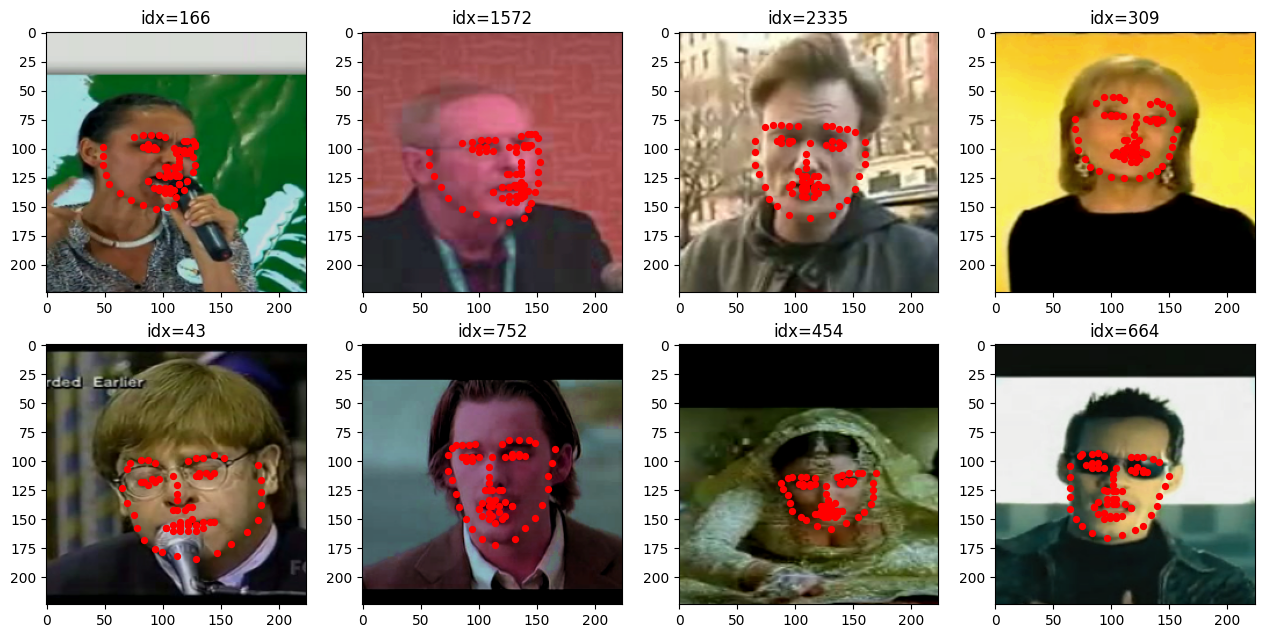

In [6]:
train_dataset.show_random_samples(n_samples=8)

### Détecter le device disponible

- Détecter automatiquement le device disponible : CUDA (GPU NVIDIA), MPS (GPU Apple Silicon) ou CPU
- Utiliser `torch.device()` avec les conditions appropriées pour tester `torch.cuda.is_available()` et `torch.backends.mps.is_available()`
- Afficher le device sélectionné

In [7]:
# Détection du device (mps pour les Mac M1/M2)
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", device)

Using device: cuda


### Créer les DataLoaders

- Définir la constante `BATCH_SIZE` : 32 si le device est CUDA, sinon 16 pour éviter la saturation mémoire CPU
- Créer `train_loader` avec `DataLoader` en passant `train_dataset`, le batch size et **impérativement** `shuffle=True` pour mélanger les données à chaque époque
- Créer `val_loader` avec `val_dataset`, le batch size et `shuffle=False`
- Créer `test_loader` avec `test_dataset`, le batch size et `shuffle=False`
- Afficher le nombre de batchs dans chaque loader

In [8]:
# Création des DataLoaders

BATCH_SIZE =  32 if str(device) == "cuda" else 4 # pour ne pas saturer la mémoire CPU
print(f"Batch size: {BATCH_SIZE}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # IMPORTANT: shuffle=True pour l'entraînement !
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train loader batches: {len(train_loader)}")
print(f"Validation loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Batch size: 32
Train loader batches: 87
Validation loader batches: 22
Test loader batches: 25


### Vérifier les dimensions des batchs

Itérer sur `train_loader` et extraire un seul batch `(images, keypoints)` :
- Afficher le numéro du batch
- Afficher la shape des images (devrait être `[batch_size, 3, 224, 224]`)
- Afficher la shape des keypoints (devrait être `[batch_size, 136]` car 68 points × 2 coordonnées)
- Utiliser `break` pour s'arrêter après le premier batch

In [9]:
# verification des shapes des batches

for idx, (images, keypoints) in enumerate(train_loader):
    print(f"Batch {idx}:")
    print(f"  x shape: {images.shape}")
    print(f"  y shape: {keypoints.shape}")
    break

Batch 0:
  x shape: torch.Size([32, 3, 224, 224])
  y shape: torch.Size([32, 136])


### Charger le modèle ResNet-50 pré-entraîné

- Charger le modèle ResNet-50 avec les poids pré-entraînés sur ImageNet en utilisant `models.resnet50(weights='IMAGENET1K_V1')` de torchvision
- Stocker le modèle dans la variable `model`
- Afficher sa structure pour l'étudier

In [10]:
# ResNet-50 est un bon choix pour la détection de keypoints faciaux
# grâce à ses connexions résiduelles qui préservent les détails spatiaux
model = models.resnet50(weights='IMAGENET1K_V1')
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 59.8MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Geler les couches du backbone pour le fine-tuning

- Parcourir tous les paramètres du modèle avec `model.named_parameters()`
- Pour chaque paramètre, vérifier si son nom contient `'layer3'`, `'layer4'` ou `'fc'`
- Si oui, mettre `param.requires_grad = True` (paramètre entraînable)
- Sinon, mettre `param.requires_grad = False` (paramètre gelé)
- Cette stratégie permet un fine-tuning progressif en ne réentraînant que les couches profondes

In [11]:
# On gèle seulement les premières couches du backbone pour permettre un fine-tuning progressif
trainable_layers = ['layer3', 'layer4', 'fc'] # ['layer4', 'fc']
for name, param in model.named_parameters():
    if any(layer in name for layer in trainable_layers):
        param.requires_grad = True
    else:
        param.requires_grad = False

In [12]:
# affiche avec summary
model.to(device)
summary(model, (3, FacesDataset.IMG_SIZE, FacesDataset.IMG_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

### Remplacer la tête de classification par une tête de régression

- Remplacer la couche fully connected finale `model.fc` par un `nn.Sequential` contenant :
    - `nn.Linear(2048, 1024)` : première couche dense réduisant de 2048 features à 1024
    - `nn.ReLU()` : activation
    - `nn.Dropout(0.5)` : régularisation avec dropout à 50%
    - `nn.Linear(1024, 512)` : deuxième couche dense à 512 unités
    - `nn.ReLU()` : activation
    - `nn.Dropout(0.3)` : régularisation avec dropout à 30%
    - `nn.Linear(512, 136)` : couche de sortie produisant 136 valeurs (68 keypoints × 2 coordonnées)
    - `nn.Sigmoid()` : activation finale pour normaliser les sorties dans [0, 1]

In [13]:
# ResNet-50 produit 2048 features en sortie (avant la couche fc)
# On remplace la couche fc finale par notre tête de régression
model.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 136),
    nn.Sigmoid()
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Vérifier les dimensions de sortie du modèle

- Passer le modèle en mode évaluation avec `model.eval()`
- Dans un contexte `torch.no_grad()`, effectuer une prédiction sur le premier échantillon de `train_dataset`
- Afficher la shape de la prédiction (devrait être `[1, 136]`)
- Afficher la shape de la vérité terrain du premier échantillon de `test_dataset` (devrait être `[136]`)

In [14]:
#vérification de la sortie du modèle avant entraînement
with torch.no_grad():
    model.eval()
    model.to(device)
    x = train_dataset[0][0].unsqueeze(0).to(device)  # Ajouter une dimension batch
    print("Prediction: ", model(x).shape)
    print("Ground Truth: ", test_dataset[0][1].shape)

Prediction:  torch.Size([1, 136])
Ground Truth:  torch.Size([136])


### Implémenter la fonction d'entraînement d'un batch

Définir la fonction `train_batch(model, x, y, loss_fn, optimizer)` qui :
- Met le modèle en mode entraînement avec `model.train()`
- Effectue une passe forward pour obtenir les prédictions
- Calcule la loss avec `loss_fn(predictions, y)`
- Effectue la rétropropagation avec `batch_loss.backward()`
- Met à jour les poids avec `optimizer.step()`
- Réinitialise les gradients avec `optimizer.zero_grad()`
- Retourne la valeur scalaire de la loss avec `.item()`

In [15]:
def train_batch(model, x, y, loss_fn, optimizer):
    """
    Train the model on a single batch of data.
    
    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to train. Will be set to training mode.
    x : torch.Tensor
        Input batch of images with shape (batch_size, channels, height, width).
    y : torch.Tensor
        Target batch of keypoint coordinates with shape (batch_size, 136).
        Contains normalized keypoint coordinates in [0, 1] range.
    loss_fn : torch.nn.Module
        The loss function used to compute the training loss (e.g., nn.L1Loss()).
    optimizer : torch.optim.Optimizer
        The optimizer used to update model parameters (e.g., Adam, SGD).
    
    Returns
    -------
    float
        The scalar loss value for this batch as a Python float.      
    """
    model.train()
    predictions = model(x)
    batch_loss = loss_fn(predictions, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

### Implémenter la métrique PCK@α pour un batch

Définir la fonction `compute_pck_batch(predictions, targets, alpha=0.1)` qui calcule le **Percentage of Correct Keypoints** à un seuil α. Cette métrique compte le pourcentage de keypoints prédits dont la distance euclidienne à la vérité terrain est inférieure à un seuil.

In [16]:
# calcul de l'accuracy d'un batch pour les keypoints selon PCK@α
@torch.no_grad()
def compute_pck_batch(predictions, targets, alpha=0.1):
    """
    Calcule le PCK@alpha (Percentage of Correct Keypoints at threshold α) pour un batch.
    
    Args:
        predictions: Tensor de shape (batch_size, 136) - prédictions du modèle
        targets: Tensor de shape (batch_size, 136) - vérité terrain
        alpha: Le seuil de tolérance (typiquement 0.1 ou 0.2)
    
    Returns:
        float: Le pourcentage de keypoints corrects pour ce batch
    """
    # Pour des coordonnées normalisées [0,1], la diagonale de l'image est sqrt(2)
    diagonal = np.sqrt(2)
    threshold = alpha * diagonal
    
    # Reshape pour avoir (batch_size, num_keypoints, 2)
    batch_size = predictions.shape[0]
    pred_kpts = predictions.view(batch_size, -1, 2)
    true_kpts = targets.view(batch_size, -1, 2)
    
    # Calcul de la distance euclidienne pour chaque keypoint
    distances = torch.sqrt(((pred_kpts - true_kpts) ** 2).sum(dim=2))
    
    # Compte le nombre de keypoints corrects
    correct = (distances < threshold).sum().item()
    total_keypoints = distances.numel()
    
    pck = (correct / total_keypoints) * 100
    return pck


### Implémenter la fonction d'évaluation sur un DataLoader

Définir la fonction `evaluate(model, data_loader, alpha=0.1, loss_fn=None, device='cpu')` qui évalue le modèle sur un ensemble de données complet.

**Fonctionnalités** :
- Passer le modèle en mode évaluation avec `model.eval()`
- Désactiver le calcul des gradients avec `torch.no_grad()`
- Parcourir tous les batchs du `data_loader` avec une barre de progression `tqdm`
- Pour chaque batch, déplacer les données sur le `device`, obtenir les prédictions
- Calculer le PCK du batch avec `compute_pck_batch()`
- Accumuler le PCK de manière pondérée par le nombre de keypoints
- Si `loss_fn` est fourni, calculer aussi la loss moyenne
- Retourner soit le PCK moyen seul, soit le tuple `(PCK_moyen, loss_moyenne)`

In [17]:
# calcul de l'accuracy d'un dataloader complet pour les keypoints selon PCK@α
def evaluate(model, data_loader, alpha=0.1, loss_fn=None, device='cpu'):    
    """
    Calcule la loss et le PCK@alpha pour un DataLoader complet.
    
    Args:
        model: Le modèle PyTorch
        data_loader: DataLoader contenant les données de test
        alpha: Le seuil de tolérance
        device: Le device sur lequel faire les calculs
        loss_fn: Fonction de loss optionnelle (si None, seul le PCK est calculé)
    
    Returns:
        float ou tuple: Le pourcentage de keypoints corrects (0-100)
                        Si loss_fn est fourni, retourne (pck, loss_moyenne)
    """
    model.eval()
    total_pck_weighted = 0.0
    total_keypoints = 0
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        loop = tqdm(data_loader, desc="Eval", leave=False)
        for x_batch, y_batch in loop:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            
            # Prédictions du modèle
            predictions = model(x_batch)
            
            # Calcul du PCK pour ce batch
            batch_pck = compute_pck_batch(predictions, y_batch, alpha)
            
            # Nombre de keypoints dans ce batch
            num_keypoints = predictions.shape[0] * (predictions.shape[1] // 2)
            
            # Accumulation pondérée du PCK
            total_pck_weighted += batch_pck * num_keypoints
            total_keypoints += num_keypoints
            
            # Calcul de la loss si demandé
            if loss_fn is not None:
                batch_loss = loss_fn(predictions, y_batch)
                batch_size = x_batch.size(0)
                total_loss += batch_loss.item() * batch_size
                total_samples += batch_size
    
    # Moyenne pondérée sur tous les batches
    avg_acc = total_pck_weighted / total_keypoints
    
    if loss_fn is not None:
        avg_loss = total_loss / total_samples
        return avg_acc, avg_loss
    
    return avg_acc


In [52]:
# Évaluer le modèle avant l'entraînement

model.to(device)
initial_val_acc, initial_val_loss = evaluate(model, val_loader, alpha=0.1, loss_fn=nn.L1Loss(), device=device)
print(f"Initial Validation Acc (PCK@0.1): {initial_val_acc:.2f}%")
print(f"Initial Validation Loss: {initial_val_loss:.4f}")

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

Initial Validation Acc (PCK@0.1): 45.51%
Initial Validation Loss: 0.0988


### Configurer la loss, l'optimiseur et le scheduler

<div style="color: gray">
<strong>Le scheduler de learning rate</strong>

Un **scheduler** (planificateur) est un mécanisme qui ajuste automatiquement le learning rate au cours de l'entraînement. Il permet d'adapter la vitesse d'apprentissage en fonction de la progression du modèle.

**Intérêt** :
- En début d'entraînement, un LR élevé permet une convergence rapide
- Plus tard, un LR plus faible permet d'affiner les poids et de stabiliser l'entraînement
- Évite de rester coincé dans des plateaux ou de diverger en fin d'entraînement

**Le scheduler ReduceLROnPlateau** :
- Surveille une métrique (ici la validation loss)
- `mode='min'` indique qu'on cherche à **minimiser** la métrique (car c'est une loss). Pour une accuracy, on utiliserait `mode='max'`
- Réduit le LR d'un facteur donné si la métrique ne s'améliore pas pendant plusieurs époques
- Exemple : si `factor=0.5` et `patience=3`, le LR sera divisé par 2 après 3 époques sans amélioration
</div>

A faire :
- Définir la fonction de loss `loss_fn = nn.L1Loss()` (MAE, adaptée pour la régression de coordonnées)
- Créer l'optimiseur Adam avec `lr=1e-4` (learning rate réduit pour le fine-tuning)
- Créer un scheduler `ReduceLROnPlateau` qui réduit le learning rate de moitié (`factor=0.5`) après 3 époques sans amélioration (`patience=3`) de la validation loss, avec `mode='min'` et `verbose=True`
- Déplacer le modèle sur le device avec `model.to(device)`
- Initialiser `pck_alpha = 0.1` (seuil pour la métrique PCK)
- Initialiser les listes vides pour stocker les historiques : `train_losses`, `train_accuracies`, `val_losses`, `val_accuracies`

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Scheduler pour réduire progressivement le learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

pck_alpha = 0.1

val_accuracies = []
train_losses = []
val_losses = []
train_accuracies = []

### Implémenter la boucle d'entraînement avec early stopping

Créer une boucle d'entraînement complète avec les fonctionnalités suivantes :

**Initialisation** :
- Fixer `n_epochs = 20` (nombre maximal d'époques)
- Définir `early_stopping_patience = 4` (arrêter si pas d'amélioration pendant 5 époques)
- Initialiser `best_val_loss = float('inf')` et `epochs_without_improvement = 0`

**Pour chaque époque** :
- Afficher le numéro de l'époque
- Parcourir `train_loader` avec `tqdm` pour afficher la progression
- Pour chaque batch : stocker la loss
- Calculer le PCK du batch en mode eval et le stocker
- Calculer les moyennes d'entraînement et les ajouter aux historiques
- Évaluer sur l'ensemble de validation avec `evaluate()`
- Afficher les métriques train et validation

**Early stopping** :
- Si la validation loss s'améliore : sauvegarder `best_val_loss` et réinitialiser le compteur
- Sinon : incrémenter le compteur et afficher le nombre d'époques sans amélioration
- Si le compteur atteint `early_stopping_patience` : arrêter l'entraînement et afficher un message

**Scheduler** :
- Appeler `scheduler.step(avg_val_loss)` pour ajuster le learning rate
- Afficher le learning rate courant

In [60]:
model.to(device)

n_epochs = 20 # nombre maximal d'époques
early_stopping_patience = 5  # nombre d'époques sans amélioration avant d'arrêter
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.2e}")
    batch_losses = []
    batch_acc = []
    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc="Train", leave=False)
    for batch_idx, (x_batch, y_batch) in loop:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Forward pass dans train_batch
        loss = train_batch(model, x_batch, y_batch, loss_fn, optimizer)
        batch_losses.append(loss)
        
        # On calcule l'accuracy en mode eval pour éviter un double forward inutile
        model.eval()
        with torch.no_grad():
            acc = compute_pck_batch(model(x_batch), y_batch, alpha=pck_alpha)
        model.train()
        batch_acc.append(acc) 
        loop.set_postfix(loss=f"{loss:.4f}, acc={acc:.2f}%") 

    avg_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(avg_loss)
    avg_acc = sum(batch_acc) / len(batch_acc)
    train_accuracies.append(avg_acc)

    avg_val_acc, avg_val_loss = evaluate(model, val_loader, alpha=pck_alpha, loss_fn=loss_fn, device=device)
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    print(f"Train Loss: {avg_loss:.4f}, Train Acc (PCK@{pck_alpha}): {avg_acc:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc (PCK@{pck_alpha}): {avg_val_acc:.2f}%")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        print(f"✓ New best validation loss: {best_val_loss:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")
        
        if epochs_without_improvement >= early_stopping_patience:
            print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss was: {best_val_loss:.4f}")
            break

    # Ajustement du learning rate basé sur la val loss    
    scheduler.step(avg_val_loss)    
    
    print("-" * 40)

Epoch 1/20
Current LR: 1.00e-04


Train:   0%|          | 0/87 [00:00<?, ?it/s]

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 0.0733, Train Acc (PCK@0.1): 70.23%
Val Loss: 0.0632, Val Acc (PCK@0.1): 71.40%
✓ New best validation loss: 0.0632
----------------------------------------
Epoch 2/20
Current LR: 1.00e-04


Train:   0%|          | 0/87 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 0.0263, Train Acc (PCK@0.1): 99.26%
Val Loss: 0.0266, Val Acc (PCK@0.1): 94.47%
No improvement for 4 epoch(s)
----------------------------------------
Epoch 14/20
Current LR: 5.00e-05


Train:   0%|          | 0/87 [00:00<?, ?it/s]

Eval:   0%|          | 0/22 [00:00<?, ?it/s]

Train Loss: 0.0250, Train Acc (PCK@0.1): 99.54%
Val Loss: 0.0242, Val Acc (PCK@0.1): 96.35%
No improvement for 5 epoch(s)

🛑 Early stopping triggered after 14 epochs
Best validation loss was: 0.0223


### Visualiser les courbes d'entraînement

Créer une figure avec deux subplots côte à côte :
- **Subplot 1** : tracer l'évolution de la loss d'entraînement et de validation au fil des époques avec `plt.plot()`, ajouter les labels, titre, légende et ajuster les xticks
- **Subplot 2** : tracer l'évolution de l'accuracy (PCK) d'entraînement et de validation au fil des époques, ajouter les labels, titre, légende et ajuster les xticks
- Étudiez l'endroit où a eu lieu le early stopping


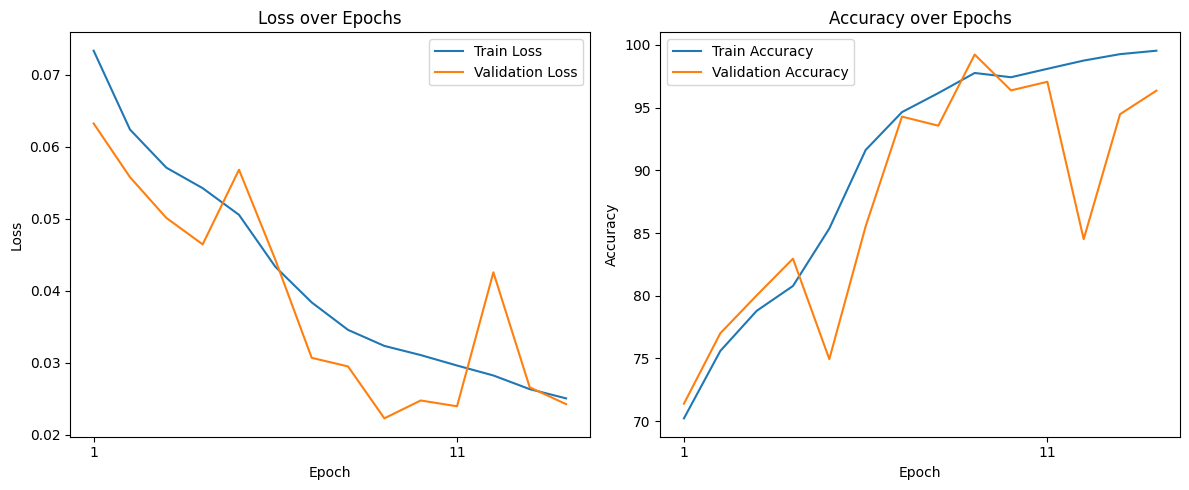

In [72]:
# Visualisation des courbes d'entrainement et de validation

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.xticks(range(1, len(train_losses)+1, 10))
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.xticks(range(1, len(train_accuracies)+1, 10))
plt.legend()

plt.tight_layout()
plt.show()

### Évaluer le modèle sur l'ensemble de test

- Appeler `evaluate()` sur `test_loader` avec `alpha=pck_alpha` et `loss_fn=None` (pas besoin de calculer la loss sur le test)
- Stocker le résultat dans `test_acc`
- Afficher le score PCK@0.1 sur le test

In [62]:
test_acc = evaluate(model, test_loader, alpha=pck_alpha, loss_fn=None, device=device)
print(f"Test Acc (PCK@{pck_alpha}): {test_acc:.2f}%")

Eval:   0%|          | 0/25 [00:00<?, ?it/s]

Test Acc (PCK@0.1): 98.57%


### Visualiser les prédictions sur des échantillons de test

Créer une figure pour afficher côte à côte les keypoints réels et prédits :
- Mettre le modèle en mode évaluation
- Sélectionner 8 indices aléatoires dans `test_dataset`
- Créer une grille 2×4 avec `plt.subplots()`
- Pour chaque échantillon : charger l'image et les keypoints réels, effectuer la prédiction avec `model()`
- Dénormaliser l'image et les keypoints (réels et prédits) pour l'affichage
- Afficher l'image avec `imshow()`
- Superposer les keypoints réels en rouge (`marker='o'`) et les prédictions en vert/lime (`marker='x'`)
- Ajouter une légende sur la première image

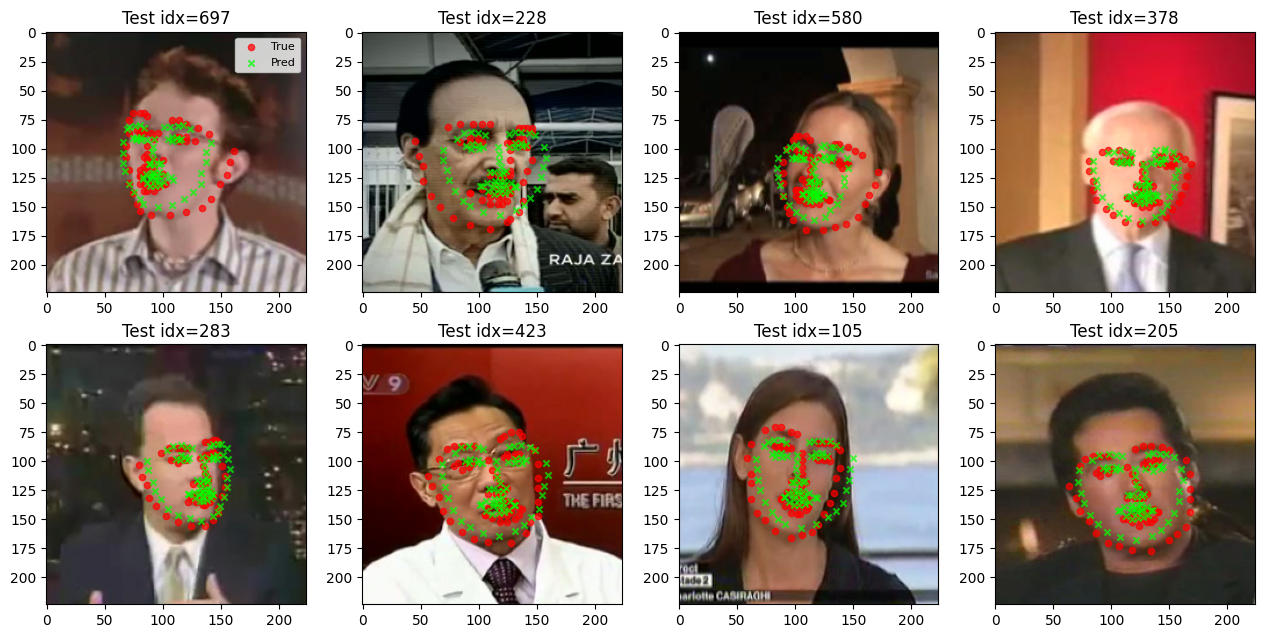

In [63]:
# affiche quelques prédictions sur le jeu de test

model.eval()
n_samples = 8
indices = np.random.choice(len(test_dataset), size=n_samples, replace=False)

cols = max(1, n_samples // 2)
rows = int(np.ceil(n_samples / cols))
plt.figure(figsize=(cols * 3.2, rows * 3.2))

with torch.no_grad():
    for i, idx in enumerate(indices):
        sample = test_dataset[idx]
        image_tensor, true_keypoints = sample
        
        # Prédiction
        image_input = image_tensor.unsqueeze(0).to(device)
        pred_keypoints = model(image_input).cpu().squeeze(0)
        
        # Dénormalisation pour l'affichage
        image, true_kps = FacesDataset.denormalize((image_tensor, true_keypoints))
        pred_kps = pred_keypoints.numpy().reshape(-1, 2) * FacesDataset.IMG_SIZE
        
        ax = plt.subplot(rows, cols, i + 1)
        ax.set_title(f'Test idx={idx}')
        ax.imshow(image)
        
        # Affichage des keypoints réels en rouge
        ax.scatter(true_kps[:, 0], true_kps[:, 1], s=20, c='red', marker='o', label='True', alpha=0.7)
        
        # Affichage des keypoints prédits en vert
        ax.scatter(pred_kps[:, 0], pred_kps[:, 1], s=20, c='lime', marker='x', label='Pred', alpha=0.7)
        
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### Préparer le chemin de sauvegarde du modèle

- Définir la variable `weights_dir` pointant vers `"../model_weights"`
- Définir le nom du fichier de poids `model_name = "08_kp_regression_resnet.pth"`
- Construire le chemin complet `weights_file` avec `os.path.join()`

In [67]:
weights_dir = "../model_weights"
model_name = "08_kp_regression_resnet.pth"
weights_file = os.path.join(weights_dir, model_name)

### Sauvegarder les poids du modèle entraîné

In [68]:
 # sauvegarde des poids du modèle entraîné
print("Saving to : ", weights_file)
# torch.save(model.state_dict(), weights_file) #commenté pour éviter une sauvegarde accidentelle

Saving to :  ../model_weights/08_kp_regression_resnet.pth


### Charger les poids d'un modèle entraîné (optionnel)

In [73]:
# chargement des poids du modèle entraîné
# model.load_state_dict(torch.load(weights_file, map_location=device, weights_only=True))
print("Model weights loaded from:", weights_file)

Model weights loaded from: ../model_weights/08_kp_regression_resnet.pth


### Implémenter une fonction de prédiction sur image arbitraire

Définir la fonction `predict_and_display_keypoints(image_path, model, dataset, device='cpu', figsize=(4, 4))` qui :

**Chargement et prétraitement** :
- Charger l'image depuis `image_path` avec PIL et la convertir en RGB puis en array NumPy
- Récupérer le pipeline de transformation sans augmentation `FacesDataset.NO_AUMENTATION`
- Appliquer la transformation à l'image

**Prédiction** :
- Mettre le modèle en mode évaluation
- Dans un contexte `torch.no_grad()`, ajouter une dimension batch avec `unsqueeze(0)`
- Déplacer sur le device, effectuer la prédiction et ramener sur CPU

**Visualisation** :
- Dénormaliser l'image en inversant la normalisation ImageNet
- Convertir les keypoints prédits en coordonnées pixel (multiplier par `IMG_SIZE`)
- Afficher l'image avec `plt.imshow()`
- Superposer les keypoints prédits avec `scatter()` en vert/lime
- Ajouter un titre avec le nom du fichier, une légende et masquer les axes
- Afficher des informations : chemin, shape originale, nombre de keypoints

**Retour** :
- Retourner l'array NumPy des keypoints prédits de shape `(68, 2)`

In [79]:
def predict_and_display_keypoints(image_path, model, augmentation, device='cpu', figsize=(4, 4)):
    """
    Prédit et affiche les keypoints faciaux pour une image donnée.
    
    Args:
        image_path: Chemin vers l'image à analyser
        model: Le modèle PyTorch entraîné
        augmentation: Transformation à appliquer (sans augmentation)
        device: Device sur lequel faire l'inférence ('cpu', 'cuda', 'mps')
        figsize: Taille de la figure matplotlib
    
    Returns:
        pred_kps: Array numpy des keypoints prédits (shape: [68, 2])
    """
    # Chargement de l'image
    image = np.array(Image.open(image_path).convert('RGB'))
    
    # Application de la transformation
    transformed = augmentation(image=image)
    image_tensor = transformed['image']
    
    # Prédiction des keypoints
    model.eval()
    with torch.no_grad():
        image_input = image_tensor.unsqueeze(0).to(device)
        pred_keypoints = model(image_input).cpu().squeeze(0)
    
    # Dénormalisation pour l'affichage
    m = FacesDataset.MEAN.view(1, 1, 3)
    s = FacesDataset.STD.view(1, 1, 3)
    image_display = image_tensor.permute(1, 2, 0) * s + m
    image_display = image_display.numpy()
    image_display = np.clip(image_display * 255.0, 0, 255).astype(np.uint8)
    
    # Conversion des keypoints en coordonnées pixel
    pred_kps = pred_keypoints.numpy().reshape(-1, 2) * FacesDataset.IMG_SIZE
    
    # Affichage
    plt.figure(figsize=figsize)
    plt.imshow(image_display)
    plt.scatter(pred_kps[:, 0], pred_kps[:, 1], s=30, c='lime', marker='x', 
                label='Keypoints prédits', alpha=0.8)
    plt.title(f'Prédiction des keypoints faciaux\n{os.path.basename(image_path)}')
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Image chargée: {image_path}")
    print(f"Shape originale: {image.shape}")
    print(f"Nombre de keypoints prédits: {len(pred_kps)}")

### Tester la prédiction sur une image personnalisée

- Appeler `predict_and_display_keypoints()` avec le chemin vers une image de test (par exemple `'../data/images/Arnold.jpg'`)
- Passer le modèle, le dataset, et le device


**NB : il se peut que le modèle ne fonctione pas bien sur vos images personnelles si elles sont trop éloignées du Dataset (cadrage, etc.)**

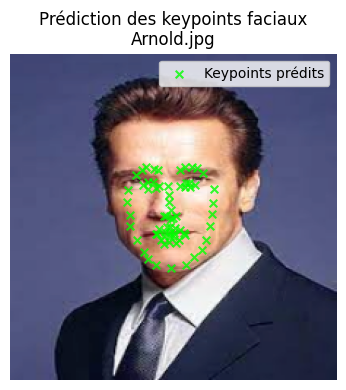

Image chargée: ../data/images/Arnold.jpg
Shape originale: (253, 199, 3)
Nombre de keypoints prédits: 68


In [80]:
# Exemples d'utilisation de la fonction

# Test avec Arnold
predict_and_display_keypoints(
    '../data/images/Arnold.jpg', 
    model, 
    FacesDataset.NO_AUGMENTATION, 
    device
)

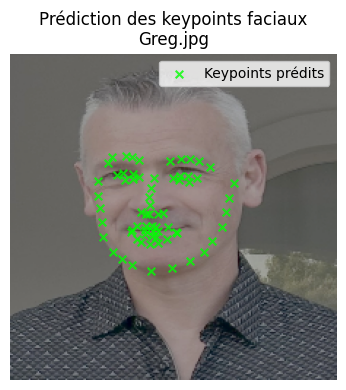

Image chargée: ../data/images/Greg.jpg
Shape originale: (810, 620, 3)
Nombre de keypoints prédits: 68


In [81]:
predict_and_display_keypoints(
    '../data/images/Greg.jpg', 
    model, 
    FacesDataset.NO_AUGMENTATION, 
    device
)

### ... Il n'y a plus qu'à implémenter vos filtres Snapchat ou TikTok préférés en utilisant les keypoints prédits ! :)